# Занятие 29. Линейная регрессия

Кластеризация помогала **находить группы без готовых ответов**. Теперь задача другая: по известным образцам будем **предсказывать число** — цену, температуру, время или результат.

К концу занятия вы сможете:

- отличать регрессию от классификации и кластеризации;
- объяснить, как линейная модель строит прогноз;
- сравнивать модели по MAE, MSE и $R^2$;
- замечать переобучение, использовать регуляризацию и масштабирование;
- замечать выбросы, связанные признаки и нелинейные зависимости.


## 1. Обучение с учителем и без

В задаче **кластеризации** мы использовали данные, в которых не было готовых ответов или подсказок. Такие задачи относят к **обучению без учителя** (*unsupervised learning*).

Чаще для обучения используются **размеченные данные** — объекты, для которых уже известны правильные ответы. Это **обучение с учителем** (*supervised learning*). К нему относятся:

- **классификация** — определение категории объекта, например «спам / не спам»;
- **регрессия** — предсказание числа, например цены или результата экзамена.


## 2. Задача регрессии

**Регрессия** — предсказание числового ответа.

| Данные об объекте | Что предсказываем |
|---|---|
| площадь квартиры, район, этаж | цену в рублях |
| часы подготовки | балл за контрольную |
| температура и влажность | расход электричества |

Сравним знакомые задачи:

- **кластеризация:** готовых ответов нет, ищем похожие группы;
- **классификация:** ответ — категория, например «спам / не спам»;
- **регрессия:** ответ — число, например 73 балла.

Будем изучать связь между временем подготовки к ЕГЭ $x$ и результатом $y$.

| часы подготовки | балл |
|-----------------|------|
| 1 | 42 |
| 2 | 48 |
| 3 | 65 |
| 4 | 71 |
| 5 | 68 |
| 6 | 84 |
| 7 | 82 |


In [19]:
import numpy as np
import matplotlib.pyplot as plt

hours = np.array([1, 2, 3, 4, 5, 6, 7], dtype=float)
scores = np.array([42, 48, 65, 71, 68, 84, 82], dtype=float)


,часы подготовки,балл
0,1.0,42.0
1,2.0,48.0
2,3.0,65.0
3,4.0,71.0
4,5.0,68.0
5,6.0,84.0
6,7.0,82.0


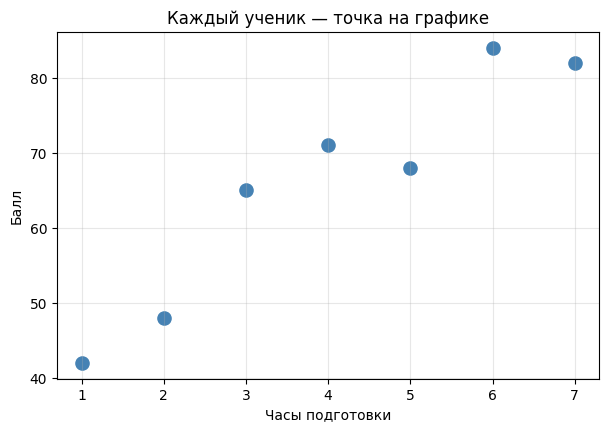

In [20]:
plt.figure(figsize=(7, 4.5))
plt.scatter(hours, scores, s=90, color='steelblue')
plt.xlabel('Часы подготовки')
plt.ylabel('Балл')
plt.title('Каждый ученик — точка на графике')
plt.grid(alpha=0.3)
plt.show()


## 3. Линейная регрессия с одним признаком

Простейшая модель проводит прямую:

$$\hat y = wx + b$$

- $x$ — известный признак;
- $\hat y$ (читается «игрек с крышкой») — прогноз;
- $w$ — **наклон**: насколько меняется прогноз при увеличении $x$ на 1;
- $b$ — **смещение**: прогноз при $x=0$.

Если $w=6{,}5$, каждый дополнительный час связан примерно с ростом прогноза на 6,5 балла. Это связь в данных, а не доказательство причины: сама по себе формула не доказывает, что именно часы вызвали рост. Например, зонтики часто встречаются рядом с лужами, но зонтики не создают лужи: и то и другое связано с дождём.


In [21]:
from sklearn.linear_model import LinearRegression

X = hours.reshape(-1, 1)  # sklearn ожидает таблицу признаков
model = LinearRegression()
model.fit(X, scores)

w = model.coef_[0]
b = model.intercept_
print(f'Формула: балл ≈ {w:.2f} · часы + {b:.2f}')
print(f'Прогноз для 8 часов: {model.predict([[8]])[0]:.1f}')


Формула: балл ≈ 6.96 · часы + 37.86
Прогноз для 8 часов: 93.6


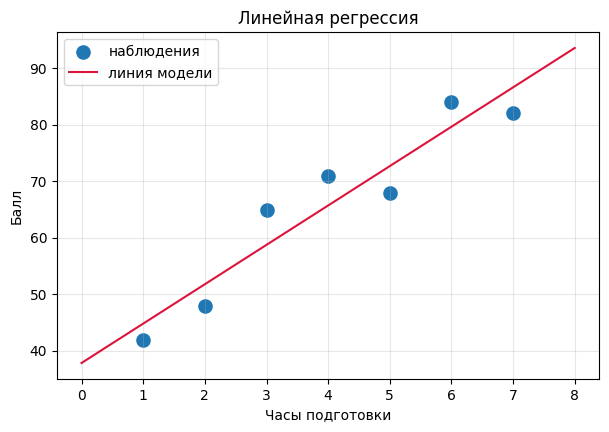

In [22]:
grid = np.linspace(0, 8, 100)
plt.figure(figsize=(7, 4.5))
plt.scatter(hours, scores, s=90, label='наблюдения')
plt.plot(grid, model.predict(grid.reshape(-1, 1)), color='crimson', label='линия модели')
plt.xlabel('Часы подготовки'); plt.ylabel('Балл')
plt.title('Линейная регрессия')
plt.grid(alpha=0.3); plt.legend(); plt.show()


## 4. Ошибка модели и MSE

Для каждой точки есть **остаток** (ошибка):

$$e_i = y_i - \hat y_i.$$

У одной точки ошибка положительная, у другой отрицательная. Простое среднее может дать ноль, хотя прогнозы неточны. Поэтому часто используют функцию потерь **MSE** (*Mean Squared Error* — средняя квадратичная ошибка), в которой ошибки возводят в квадрат:

$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2.$$

Геометрически $(y_i-\hat y_i)^2$ — площадь квадрата со стороной, равной длине ошибки. Большая ошибка получает особенно большой штраф.

Можно использовать и модули ошибок. Однако функция с модулем имеет «угол» в нуле, поэтому обычная производная там не определена. Оптимизировать такие функции всё равно можно, но для первого знакомства квадраты удобнее.


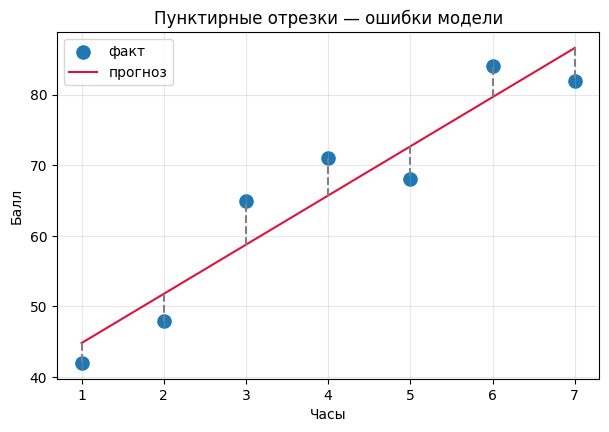

In [23]:
pred = model.predict(X)
residuals = scores - pred

plt.figure(figsize=(7, 4.5))
plt.scatter(hours, scores, s=90, label='факт')
plt.plot(hours, pred, color='crimson', label='прогноз')
for x, y, y_hat in zip(hours, scores, pred):
    plt.plot([x, x], [y_hat, y], color='gray', linestyle='--')
plt.title('Пунктирные отрезки — ошибки модели')
plt.xlabel('Часы'); plt.ylabel('Балл'); plt.grid(alpha=0.3); plt.legend(); plt.show()



## 5. Как находится лучшая прямая *

Алгоритм подбирает $w$ и $b$, чтобы MSE была минимальна. Представьте холмистую поверхность: высота — ошибка, координаты — значения $w$ и $b$. Нужно попасть в самую низкую точку.

Есть два основных пути.

1. **Прямое решение.** Если вы уже знакомы с производными, с их помощью можно записать условия минимума и решить систему уравнений. Для одного признака получается
   $$w=\frac{\sum(x_i-\bar x)(y_i-\bar y)}{\sum(x_i-\bar x)^2},\qquad b=\bar y-w\bar x,$$
   где через $\bar x$ и $\bar y$ обозначены средние арифметические.
2. **Градиентный спуск.** Начать с произвольных коэффициентов и много раз делать маленький шаг в сторону уменьшения ошибки.

Ниже — вид сверху на «ландшафт ошибки». Замкнутые линии соединяют точки с одинаковой MSE, как горизонтали на географической карте. Красные точки показывают последовательные шаги к минимуму.

<svg width="620" height="310" viewBox="0 0 620 310" xmlns="http://www.w3.org/2000/svg" role="img" aria-label="Градиентный спуск движется по линиям уровня MSE к минимуму">
  <defs>
    <marker id="arrow" markerWidth="9" markerHeight="9" refX="7" refY="3" orient="auto"><path d="M0,0 L0,6 L8,3 z" fill="#c62828"/></marker>
  </defs>
  <rect x="1" y="1" width="618" height="308" rx="12" fill="#fafafa" stroke="#dddddd"/>
  <text x="310" y="27" text-anchor="middle" font-size="17" font-family="sans-serif">Вид сверху на поверхность MSE</text>
  <ellipse cx="330" cy="170" rx="245" ry="115" fill="#e8f1fa" stroke="#6b9ac4" stroke-width="2"/>
  <ellipse cx="330" cy="170" rx="175" ry="80" fill="#d7e8f7" stroke="#5689b4" stroke-width="2"/>
  <ellipse cx="330" cy="170" rx="105" ry="46" fill="#c3ddf2" stroke="#3f78a8" stroke-width="2"/>
  <ellipse cx="330" cy="170" rx="37" ry="17" fill="#a9d0ed" stroke="#245f91" stroke-width="2"/>
  <circle cx="330" cy="170" r="6" fill="#174d78"/>
  <text x="339" y="160" font-size="13" font-family="sans-serif">минимум MSE</text>
  <polyline points="105,83 168,109 220,128 263,145 297,157 320,166" fill="none" stroke="#c62828" stroke-width="3" marker-mid="url(#arrow)" marker-end="url(#arrow)"/>
  <g fill="#c62828"><circle cx="105" cy="83" r="6"/><circle cx="168" cy="109" r="6"/><circle cx="220" cy="128" r="6"/><circle cx="263" cy="145" r="6"/><circle cx="297" cy="157" r="6"/><circle cx="320" cy="166" r="6"/></g>
  <text x="62" y="69" font-size="13" font-family="sans-serif" fill="#c62828">старт</text>
  <line x1="65" y1="275" x2="575" y2="275" stroke="#555" marker-end="url(#arrow)"/><text x="580" y="281" font-size="14" font-family="sans-serif">w</text>
  <line x1="65" y1="275" x2="65" y2="43" stroke="#555" marker-end="url(#arrow)"/><text x="54" y="42" font-size="14" font-family="sans-serif">b</text>
</svg>

Прямое решение средствами линейной алгебры быстро работает для небольших таблиц. Градиентный спуск удобнее для огромных данных и сложных моделей, но требует подобрать размер шага и число итераций.

**А что делает sklearn?** Обычный `LinearRegression` из sklearn не выполняет показанный выше градиентный спуск: он решает задачу наименьших квадратов прямым численным методом линейной алгебры. Градиентный спуск можно встретить, например, в `SGDRegressor`, а также при обучении больших и более сложных моделей. Какой бы способ поиска коэффициентов ни использовался, цель остаётся той же — уменьшить функцию потерь.


In [24]:
# Проверим формулу точного решения
x_mean, y_mean = hours.mean(), scores.mean()
w_manual = np.sum((hours - x_mean) * (scores - y_mean)) / np.sum((hours - x_mean)**2)
b_manual = y_mean - w_manual * x_mean
print(f'Вручную по формуле: w={w_manual:.2f}, b={b_manual:.2f}')
assert np.isclose(w_manual, w) and np.isclose(b_manual, b)


Вручную по формуле: w=6.96, b=37.86


Градиентный спуск: w=6.96, b=37.86


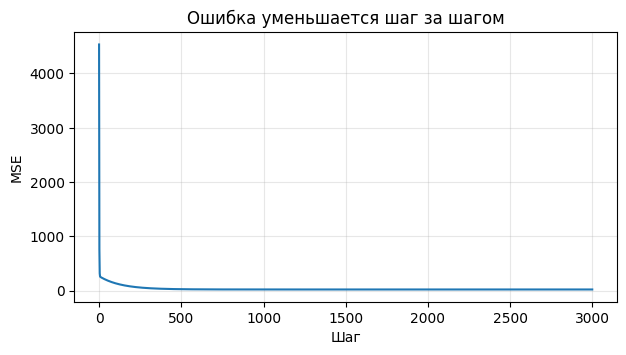

In [25]:
# Упрощённый градиентный спуск: ищем w и b маленькими шагами
w_gd, b_gd = 0.0, 0.0
learning_rate = 0.01
history = []
for step in range(3000):
    p = w_gd * hours + b_gd
    error = p - scores
    w_gd -= learning_rate * 2 * np.mean(error * hours)
    b_gd -= learning_rate * 2 * np.mean(error)
    history.append(np.mean(error**2))

print(f'Градиентный спуск: w={w_gd:.2f}, b={b_gd:.2f}')
plt.figure(figsize=(7, 3.5)); plt.plot(history)
plt.xlabel('Шаг'); plt.ylabel('MSE'); plt.title('Ошибка уменьшается шаг за шагом')
plt.grid(alpha=0.3); plt.show()


## 6. Метрики качества: MAE, MSE и RMSE

MSE может играть две роли: быть функцией потерь во время обучения и метрикой после обучения. Роль определяется тем, как именно мы её используем.

| Метрика | Формула | Особенность |
|---|---|---|
| MAE | $\frac1n\sum\lvert y_i-\hat y_i\rvert$ | понятна в единицах ответа, лояльнее к редким большим ошибкам |
| MSE | $\frac1n\sum(y_i-\hat y_i)^2$ | сильно штрафует большие промахи, измеряется в квадратных единицах |
| RMSE | $\sqrt{MSE}$ | тоже чувствительна к большим промахам, но снова в единицах ответа |

«Лучшая» метрика зависит от задачи. Если ошибка на 20 баллов намного опаснее двух ошибок по 10, полезна MSE/RMSE. Если важна типичная ошибка в понятных единицах — MAE.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Пока это учебный расчёт на тех же данных, по которым модель обучалась.
mae = mean_absolute_error(scores, pred)
mse = mean_squared_error(scores, pred)
rmse = np.sqrt(mse)
print('Метрики на обучающих данных:')
print(f'MAE = {mae:.2f} балла')
print(f'MSE = {mse:.2f} балла²')
print(f'RMSE = {rmse:.2f} балла')
print('Вывод: модель близко описывает известные точки, но это ещё не проверка на новых учениках.')


## 7. Константный baseline и $R^2$

Перед сложной моделью нужен простой соперник — **baseline**. Для MSE разумный константный baseline всегда предсказывает среднее значение $\bar y$.

Сравним сумму квадратов ошибок модели с ошибками baseline. Доля ошибки baseline, которую модель смогла устранить, описывается **коэффициентом детерминации** $R^2$:

$$R^2 = 1-\frac{\sum(y_i-\hat y_i)^2}{\sum(y_i-\bar y)^2}.$$

- $R^2=1$ — идеальные прогнозы на оцениваемом наборе;
- $R^2=0$ — качество константного прогноза средним;
- $R^2<0$ — модель хуже этого baseline.

Отрицательный $R^2$ вполне возможен на тестовых данных. На обучающих данных обычная линейная регрессия со свободным членом подбирает коэффициенты не хуже среднего, поэтому её обучающий $R^2$ неотрицателен.

Универсальной границы «хорошего» $R^2$ нет: в одной предметной области $0{,}5$ может быть полезным результатом, а в другой $0{,}95$ — недостаточным. $R^2$ не означает «процент правильных ответов».

При добавлении признаков обучающий $R^2$ не уменьшается, даже если новый признак бесполезен. Скорректированный $R^2$ (*adjusted $R^2$*) вводит штраф за число признаков, но окончательную проверку всё равно проводят на отдельных данных.


In [ ]:
baseline = np.full_like(scores, scores.mean())
print('Сравнение на обучающих данных:')
print(f'MSE baseline: {mean_squared_error(scores, baseline):.2f}')
print(f'MSE модели:   {mean_squared_error(scores, pred):.2f}')
print(f'R² модели:    {r2_score(scores, pred):.3f}')
print('Вывод: модель объясняет известные точки лучше среднего, но обобщение проверим отдельно.')


## 8. Train / validation / test для регрессии

Оценивать модель только на тех же примерах, по которым она училась, нечестно: это как давать на контрольной заранее известные задачи. Данные заранее делят на:

- **train** — модель подбирает коэффициенты;
- **validation** — выбираются признаки, регуляризация и другие настройки;
- **test** — одна итоговая проверка уже выбранного решения.

Небольшой кодовый пример ниже сравнивает train и test для одной заранее зафиксированной модели. В полном проекте варианты модели выбирают только по validation или кросс-валидации.


## 9. Когда линейная модель переобучается

Линейная регрессия тоже может переобучиться:

1. Если признаков много, а объектов мало, модель может запомнить обучающие примеры вместе с шумом.
2. Сложные признаки ($x^2$, $x^3$, $x_1x_2$ и другие) позволяют построить очень гибкую зависимость, которая «обовьёт» случайные отклонения.
3. Если решения о признаках и настройках принимались после просмотра test, модель косвенно подстроилась и под него.

Мультиколлинеарность похожих признаков усиливает нестабильность весов — подробнее в п. 16.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, scores, test_size=2, random_state=42
)
check_model = LinearRegression().fit(X_train, y_train)
train_mae = mean_absolute_error(y_train, check_model.predict(X_train))
test_mae = mean_absolute_error(y_test, check_model.predict(X_test))
print(f'MAE на обучении: {train_mae:.2f}')
print(f'MAE на тесте:    {test_mae:.2f}')
print('Вывод: тестовая ошибка заметно выше. При семи объектах оценка очень нестабильна,')
print('поэтому в настоящей задаче понадобится больше данных или кросс-валидация.')


## 10. Множественная линейная регрессия

Чаще признаков несколько:

$$\hat y=w_1x_1+w_2x_2+\ldots+w_px_p+b.$$

Например, цену квартиры можно оценивать по площади, расстоянию до центра и этажу. Модель всё ещё **линейна по коэффициентам**: каждый признак умножается на свой вес, результаты складываются.

Если остальные признаки не меняются, $w_j$ показывает, как изменится прогноз при росте $x_j$ на 1. Но это осторожная интерпретация, а не доказательство причинности.


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

apartments = pd.DataFrame({
    'площадь': [30, 40, 50, 60, 70, 80],
    'до_центра_км': [2, 8, 5, 10, 4, 12],
    'цена_млн': [7.1, 6.9, 9.8, 9.5, 13.5, 12.2]
})
multi = LinearRegression().fit(apartments[['площадь', 'до_центра_км']], apartments['цена_млн'])
area_weight, distance_weight = multi.coef_
print(f'Вес площади: {area_weight:.3f} млн рублей за 1 м²')
print(f'Вес расстояния: {distance_weight:.3f} млн рублей за 1 км')
print(f'Смещение: {multi.intercept_:.3f}')
print('Вывод: при неизменном втором признаке площадь повышает прогноз,')
print('а дополнительный километр до центра — понижает. Это связь, а не доказанная причина.')


## 11. Когда линейная модель не работает

Прямая плохо описывает:

- изгибы и волны;
- резкие пороги;
- взаимодействия признаков («эффект одного зависит от другого»);
- прогнозы далеко за пределами изученного диапазона (**экстраполяцию**).

Это видно по графику остатков: если вместо случайного облака появляется дуга или узор, модель пропустила закономерность.


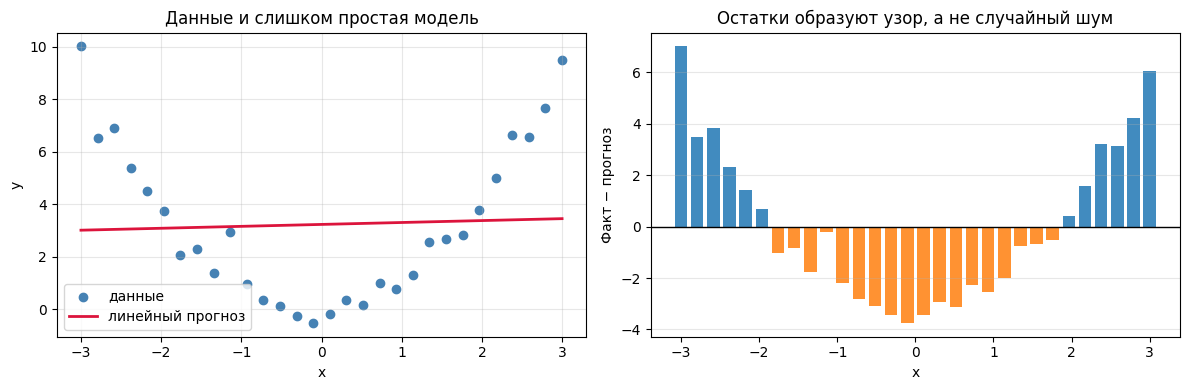

In [28]:
x_curve = np.linspace(-3, 3, 30)
y_curve = x_curve**2 + np.random.default_rng(3).normal(0, 0.5, len(x_curve))
line = LinearRegression().fit(x_curve.reshape(-1, 1), y_curve)
curve_pred = line.predict(x_curve.reshape(-1, 1))

residuals_curve = y_curve - curve_pred
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(x_curve, y_curve, color='steelblue', label='данные')
axes[0].plot(x_curve, curve_pred, color='crimson', linewidth=2, label='линейный прогноз')
axes[0].set_title('Данные и слишком простая модель')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].grid(alpha=0.3); axes[0].legend()

# Палочки показывают величину и знак каждой отдельной ошибки.
colors = np.where(residuals_curve >= 0, 'tab:blue', 'tab:orange')
axes[1].bar(x_curve, residuals_curve, width=0.16, color=colors, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Остатки образуют узор, а не случайный шум')
axes[1].set_xlabel('x'); axes[1].set_ylabel('Факт − прогноз')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 12. Линейная регрессия умеет строить кривые *

Слово «линейная» относится не обязательно к форме графика, а к тому, **как входят коэффициенты**. Добавим новый признак $x^2$:

$$\hat y=w_1x+w_2x^2+b.$$

Это парабола по $x$, но линейная комбинация признаков $x$ и $x^2$. Аналогично можно добавить $x^3$, синусы или произведения признаков. Главное — не увлечься: много степеней легко приводит к переобучению.


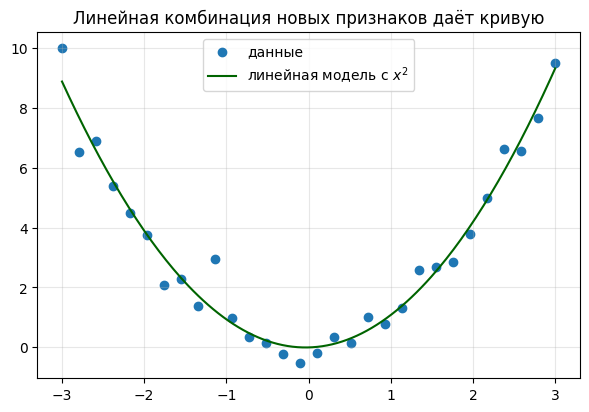

In [30]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_curve_poly = poly.fit_transform(x_curve.reshape(-1, 1))

poly_model = LinearRegression()
poly_model.fit(X_curve_poly, y_curve)

dense = np.linspace(-3, 3, 200).reshape(-1, 1)
dense_poly = poly.transform(dense)
plt.figure(figsize=(7, 4.5))
plt.scatter(x_curve, y_curve, label='данные')
plt.plot(dense, poly_model.predict(dense_poly), color='darkgreen', label='линейная модель с $x^2$')
plt.title('Линейная комбинация новых признаков даёт кривую')
plt.grid(alpha=0.3); plt.legend(); plt.show()


## 13. Регуляризация: ограничитель сложности *

Когда коэффициенты становятся огромными, модель слишком резко реагирует на небольшие изменения признаков. **Регуляризация** добавляет к функции потерь еще одно слагаемое - штраф за большие коэффициенты.

- **Ridge (L2):** штраф $\alpha\sum w_j^2$. Обычно уменьшает все веса, но редко делает их ровно нулевыми.
- **Lasso (L1):** штраф $\alpha\sum|w_j|$. Может сам обнулить часть весов — получается автоматический отбор признаков.
- **ElasticNet:** сочетает L1 и L2 в некоторой настраиваемой пользователем пропорции.

$\alpha$ управляет силой штрафа. Слишком малый штраф почти ничего не меняет; слишком большой приводит к недообучению.


In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# Два почти одинаковых признака: часы и минуты, переведённые обратно в часы
X_related = np.column_stack([hours, hours + np.array([0.1, -0.1, 0, 0.1, -0.1, 0, 0.1])])
for name, estimator in [
    ('Без штрафа', LinearRegression()),
    ('L2 / Ridge', Ridge(alpha=10)),
    ('L1 / Lasso', Lasso(alpha=1)),
    ('ElasticNet', ElasticNet(alpha=1, l1_ratio=0.5)),
]:
    estimator.fit(X_related, scores)
    print(f'{name:12}: веса {np.round(estimator.coef_, 2)}')

print('\nВывод: пример показывает поведение коэффициентов, а не выбирает лучшую модель.')
print('Для честного выбора alpha и типа регуляризации нужно сравнивать качество на валидации.')


## 14. Почему важно масштабирование *

Один признак может измеряться десятками, другой — миллионами. Для градиентного спуска это создаёт вытянутый «овраг»: к минимуму идти труднее. При регуляризации единицы измерения также влияют на размеры коэффициентов и штраф.

**StandardScaler** преобразует каждый признак так, чтобы его среднее стало равно 0, а стандартное отклонение — 1. Стандартное отклонение — это квадратный корень из среднего квадрата отклонений значений от среднего.

Масштабирование особенно важно перед градиентными методами, Ridge, Lasso и ElasticNet. Для обычной линейной регрессии с прямым решением оно не обязательно для прогноза, но помогает сравнивать коэффициенты.

В настоящей задаче `scaler.fit(...)` выполняют **только на обучающей выборке**, а тест преобразуют уже обученным `scaler.transform(...)`. Иначе информация из теста просочится в обучение.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Здесь вся таблица используется только для демонстрации преобразования.
scaler = StandardScaler()
X_related_scaled = scaler.fit_transform(X_related)

scaled_ridge = Ridge(alpha=1)
scaled_ridge.fit(X_related_scaled, scores)
print('Средние после StandardScaler:', np.round(X_related_scaled.mean(axis=0), 6))
print('Стандартные отклонения:', np.round(X_related_scaled.std(axis=0), 6))
print('Вывод: оба признака теперь находятся в одном масштабе.')


## 15. Выбросы и робастные методы *

**Выброс** — необычно далёкое наблюдение. Из-за квадратов в MSE одна такая точка способна заметно потянуть прямую к себе.

Сначала выброс нужно проверить: это ошибка измерения или редкий, но настоящий случай? Автоматически удалять его нельзя. Если необычные случаи реальны, можно сравнить MAE и MSE или использовать робастные (устойчивые к выбросам) модели, например `HuberRegressor` и `RANSACRegressor`.


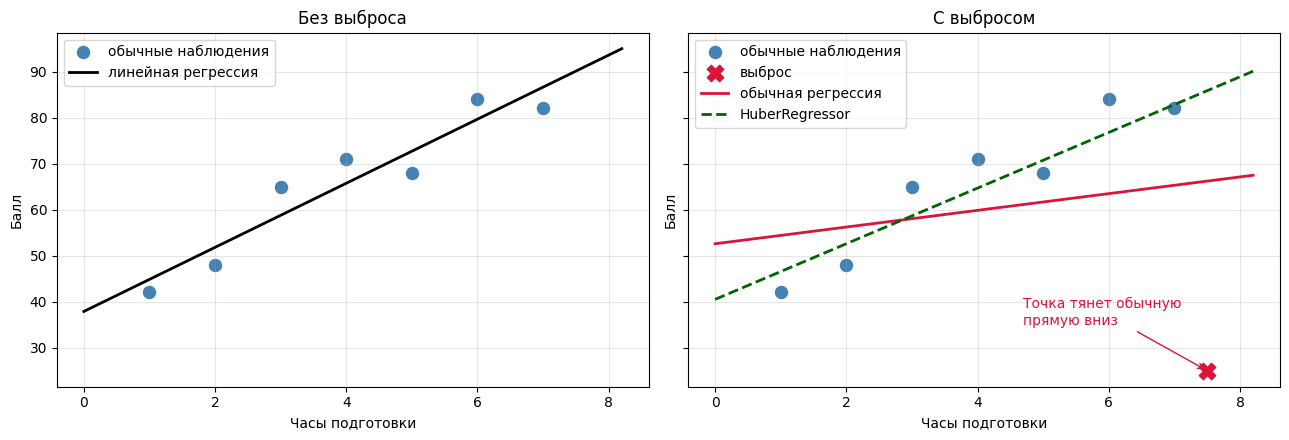

In [34]:
from sklearn.linear_model import HuberRegressor

x_out = np.append(hours, 7.5)
y_out = np.append(scores, 25)  # необычная точка
ordinary = LinearRegression().fit(x_out.reshape(-1, 1), y_out)
robust = HuberRegressor().fit(x_out.reshape(-1, 1), y_out)

clean = LinearRegression().fit(hours.reshape(-1, 1), scores)
grid = np.linspace(0, 8.2, 100).reshape(-1, 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)

# Слева — закономерность до появления выброса.
axes[0].scatter(hours, scores, s=75, color='steelblue', label='обычные наблюдения')
axes[0].plot(grid, clean.predict(grid), color='black', linewidth=2, label='линейная регрессия')
axes[0].set_title('Без выброса')
axes[0].legend()

# Справа хорошо видно, какую модель выброс тянет к себе.
axes[1].scatter(hours, scores, s=75, color='steelblue', label='обычные наблюдения')
axes[1].scatter([7.5], [25], s=140, color='crimson', marker='X', label='выброс')
axes[1].plot(grid, ordinary.predict(grid), color='crimson', linewidth=2, label='обычная регрессия')
axes[1].plot(grid, robust.predict(grid), color='darkgreen', linewidth=2, linestyle='--', label='HuberRegressor')
axes[1].annotate('Точка тянет обычную\nпрямую вниз', xy=(7.5, 25), xytext=(4.7, 35),
                 arrowprops={'arrowstyle': '->', 'color': 'crimson'}, color='crimson')
axes[1].set_title('С выбросом')
axes[1].legend(loc='upper left')

for ax in axes:
    ax.set_xlabel('Часы подготовки')
    ax.set_ylabel('Балл')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 16. Мультиколлинеарность *

**Мультиколлинеарность** возникает, когда признаки сильно связаны друг с другом: например, длина в метрах и та же длина в сантиметрах.

Как заметить:

- посмотреть корреляции числовых признаков;
- построить диаграммы рассеяния;
- проверить, сильно ли меняются веса при небольшом изменении обучающих данных.

Почему это плохо: прогноз внутри знакомого диапазона может оставаться хорошим, но модель не понимает, как «поделить заслугу» между похожими признаками. Поэтому коэффициенты становятся нестабильными, иногда большими и с неожиданными знаками. Особенно осторожно нужно интерпретировать веса и прогнозировать необычные комбинации признаков.

Помогают:

- удаление признаков, дублирующих один и тот же смысл;
- объединение признаков;
- Ridge-регуляризация.

Lasso может оставить один из нескольких похожих признаков, но выбор между ними бывает нестабильным.


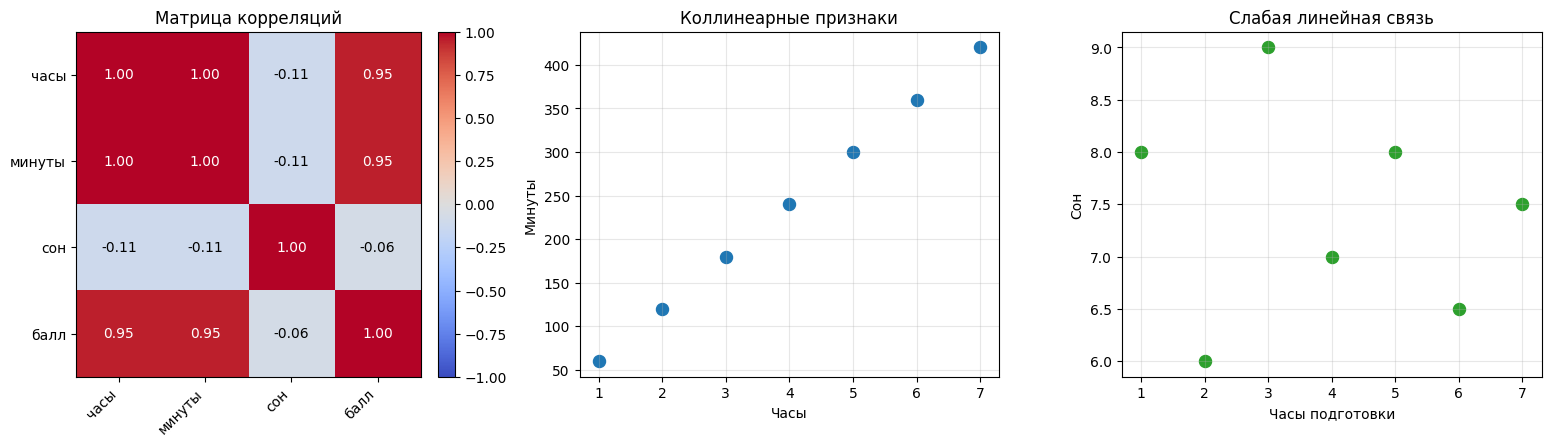

In [35]:
import pandas as pd
corr = pd.DataFrame(X_related, columns=['часы', 'почти те же часы']).corr()
corr.style.format('{:.3f}')

multi_features = pd.DataFrame({
    'часы': hours,
    'минуты': hours * 60,                 # тот же признак в других единицах
    'сон': [8, 6, 9, 7, 8, 6.5, 7.5],   # отдельный признак
    'балл': scores,
})
corr = multi_features.corr()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Тепловая карта: тёмно-красные и тёмно-синие клетки означают сильную связь.
image = axes[0].imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
axes[0].set_yticks(range(len(corr.index)), corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        axes[0].text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                     color='white' if abs(corr.iloc[i, j]) > 0.65 else 'black')
axes[0].set_title('Матрица корреляций')
fig.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04)

# Идеальная прямая выдаёт дубликат признака.
axes[1].scatter(multi_features['часы'], multi_features['минуты'], s=75)
axes[1].set_title('Коллинеарные признаки')
axes[1].set_xlabel('Часы'); axes[1].set_ylabel('Минуты')
axes[1].grid(alpha=0.3)

# Здесь точки не лежат на одной прямой: сильной линейной связи нет.
axes[2].scatter(multi_features['часы'], multi_features['сон'], s=75, color='tab:green')
axes[2].set_title('Слабая линейная связь')
axes[2].set_xlabel('Часы подготовки'); axes[2].set_ylabel('Сон')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 17. Алгоритм работы над задачей регрессии

1. Понять, какое число предсказываем, в какой момент и зачем.
2. Отделить test подходящим способом **до** исследования и настройки.
3. Исследовать только train: пропуски, распределения, выбросы и связи.
4. Выбрать метрику и построить константный baseline.
5. Обучить простую линейную регрессию.
6. По validation или кросс-валидации выбирать признаки, масштабирование, регуляризацию и другие настройки.
7. Анализировать остатки и ошибки на отдельных объектах validation.
8. Зафиксировать выбранный процесс и переобучить его на train+validation.
9. Один раз проверить качество на test и честно описать ограничения.
